# iprPy viscosity_green_kubo calculation

In [1]:
# Standard library imports
import datetime
from copy import deepcopy

# http://www.numpy.org/
import numpy as np

# https://ipython.org/
from IPython.display import display, Code, Markdown, Pretty, Image

import matplotlib.pyplot as plt

# https://github.com/usnistgov/atomman
import atomman as am
import atomman.unitconvert as uc

# https://github.com/usnistgov/iprPy
import iprPy

print('Notebook last executed on', datetime.date.today(), 'using iprPy version', iprPy.__version__)

Notebook last executed on 2026-07-07 using iprPy version 0.12.a


## 1. Load calculation and view description

### 1.1. Load the calculation

In [2]:
# Load the calculation being demoed
calculation = iprPy.load_calculation('viscosity_green_kubo')

### 1.2. Display calculation description and theory

In [3]:
# Display main docs and theory
display(Markdown(calculation.maindoc))
display(Markdown(calculation.theorydoc))

# viscosity_green_kubo calculation style

**Lucas M. Hale**, [lucas.hale@nist.gov](mailto:lucas.hale@nist.gov?Subject=ipr-demo), *Materials Science and Engineering Division, NIST*.

## Introduction

The viscosity_green_kubo calculation style estimates the shear viscosity of a liquid using the equlibrium Green-Kubo method.

### Version notes

- 2025-??: Initial version of the calculation added.
- 2026-: Calculation updated for the new LAMMPS interface. 

### Additional dependencies

### Disclaimers

- [NIST disclaimers](http://www.nist.gov/public_affairs/disclaimer.cfm)
- 

## Theory and methodology

The Green-Kubo method allows for the viscosity to be estimated during an equilibrium molecular dynamics simulation using the autocorrelation of the off-diagonal (i.e. shear) pressure components.

$$ \eta = \frac{V}{k_B T} \int_0^{\infty}{\left<P_{\alpha\beta}(0) P_{\alpha\beta}(t)\right>dt} $$

In the simulation method, the pressure autocorrelations are computed using the LAMMPS "fix ave/correlate" command allowing for slightly smoother results by averaging the correlation over a few timesteps. The integral is then numerically estimated using the trapezoidal method.  As there are three shear pressures, this gives three separate estimates for the shear viscosity which are averaged together.  Once the integral is computed in LAMMPS, it is multiplied by the preceding factor to compute the shear viscosity.

The integral part of this calculation is known to converge very slowly, and therefore requires long simulation runs (typically > 1,000,000 steps) for good estimates.  Fluctuations in the integral can also be reduced by increasing the system dimensions.

## 2. Display the underlying code

This section displays the underlying code used when calculation.calc() is called in Section 4. It is provided here allowing any users to see and understand how the calculation works.

Feel free to modify and test the functions for yourself!  You can do this by
1. Copy the Python code displayed here into a "Code" cell and run it.
2. In Section 2.2, set "savefiles = True" and run the cell to save any supporting non-python files to the working directory.
3. In Section 4, call the primary calculation function directly rather than using calculation.calc().

### 2.1. Show code and supporting file names and content

In [4]:
# Display calculation code and supporting files
for filename, contents in calculation.files.items():
    display(Markdown(f'## Contents of file "{filename}"'))
    if filename[-3:] == '.py':
        display(Code(contents, language='python'))
    else:
        display(Pretty(contents))

## Contents of file "viscosity_green_kubo.py"

# Python script created by Peter Winstel and Lucas Hale

# Standard library imports
from typing import Optional, Union

import matplotlib.pyplot as plt

# https://github.com/usnistgov/atomman
import atomman as am
import atomman.unitconvert as uc
from atomman.typing import lammpspotential, unitfloat
from atomman.lammps import LAMMPS, LAMMPSobj

def viscosity_green_kubo(lammps_command: Union[str, LAMMPSobj],
                         system: am.System,
                         potential: lammpspotential,
                         temperature: float,
                         mpi_command: Optional[str] = None,
                         timestep: Optional[unitfloat] = None,
                         runsteps: int = 1000000,
                         equilsteps: int = 0,
                         createvelocities: bool = False,
                         randomseed: Optional[int] = None,
                         usefiles: bool = False) -> dict:
    """
    Calculates the viscosity for a liquid system using the Green-Kubo
    method.

    Parameters
    ----------
    lammps_command : str, LAMMPSEXE or LAMMPSLIB
        LAMMPS executable command, LAMMPS library name, or an atomman LAMMPS
        interface object.
    system : atomman.System
        The system to perform the calculation on.
    potential : atomman.lammps.Potential
        the LAMMPS implemented potential to use.
    temperature : float
        The temperature to run at.
    mpi_command : str, optional
        The MPI command for running LAMMPS in parallel. If not given, LAMMPS
        will run serially.
    timestep : float, optional
        The amount of time to increase each frame of the simulation. The 
        default value is given by the default value for the specified LAMMPS
        unit system. 
    runsteps : int, optional
        How many timesteps the simulation will run for. Default value of 1,000,000
        should be suitable for a short run. 
    thermosteps : int, optional
        How often the calculated values get stored in the thermo table of the 
        LAMMPS output. Default value of 1,000.
    equilsteps : int, optional
        How many timesteps the equilibration simulation will run for. Default 
        value of 0.
    createvelocities : bool, optional
        Setting this to True will assign new random velocities to the atoms
        prior to running.  If this is used, then it would be wise to set an
        equilsteps value to let the velocities equilibrate before running the
        main Green-Kubo run.
    randomseed : int or None, optional
        Random number seed used by LAMMPS in creating velocities.  Only used
        if resetvelocities is True.  Default is None which will select a
        random int between 1 and 900000000.
    usefiles : bool, optional
        If set to True, then all input/output files for LAMMPS will be generated.
        Default value of False will minimize the files created.
    
    Returns
    -------
    dict
        Dictionary of results consisting of keys:

        -**'viscosity_xy'** (*float*) - The calculated viscosity using only the
        Pxy pressures.
        -**'viscosity_xz'** (*float*) - The calculated viscosity using only the
        Pxz pressures.
        -**'viscosity_yz'** (*float*) - The calculated viscosity using only the
        Pyz pressures.
        -**'viscosity'** (*float*) - The calculated viscosity using all three
        shear pressures.
    """
    # Create a LAMMPS object if needed
    lmp = LAMMPS(lammps_command, mpi_command=mpi_command, potential=potential)

    logfile = 'log.lammps'
    if usefiles or not lmp.islib:
        script = 'viscosity_green_kubo.in'
    else:
        script = None

    # Check/select a randomseed value
    randomseed = am.lammps.seed(randomseed)

    # Set timestep in atomman and LAMMPS units
    if timestep is None:
        timestep_lammps = am.lammps.style.timestep(lmp.potential.units)
        timestep = uc.set_in_units(timestep_lammps, lmp.unitsdict['time'

### 2.2. Optional: Save supporting files

Set "savefiles = True" to save files locally.  

Note that the code above should be using atomman.tools.read_calc_file() to read the files, which will read any local files with matching names if they exist or read the packaged version if the local files do not exist. This means that if you save the files locally, you can modify them and see how it affects the calculation!

In [5]:
savefiles = False

if savefiles:
    for filename, contents in calculation.files.items():
        if filename[-3:] != '.py':
            with open(filename, 'w') as f:
                f.write(contents)

## 3. Specify input parameters

### 3.1. System-specific paths

- __lammps_command__ is the LAMMPS command to use (required).
- __mpi_command__ MPI command for running LAMMPS in parallel. A value of None will run simulations serially.

In [6]:
lammps_command = 'F:/LAMMPS/current/bin/lmp.exe'
mpi_command = None
#mpi_command = 'mpiexec -localonly 6'

# Optional: check that LAMMPS works and show its version 
print(f'LAMMPS version = {am.lammps.checkversion(lammps_command)["version"]}')

LAMMPS version = 23 Jun 2022 - Update 2


### 3.2. Interatomic potential

- __potential_name__ gives the name of a potential_LAMMPS record to find and download from the iprPy library.  
- __potential__ is a potential_LAMMPS or potential_LAMMPS_KIM record object (required).

See documentation for the [potentials package](https://github.com/usnistgov/potentials/tree/master/doc) for more options on finding, loading and building potential objects (doc Notebook #s 0, 5.3, 5.4 and 7).

In [7]:
potential_name = '1999--Mishin-Y--Ni--LAMMPS--ipr1'

# Retrieve potential and parameter file(s) using atomman
potential = am.load_lammps_potential(id=potential_name, getfiles=True)

### 3.3. Initial system

- __system__ is an atomman.System to use as the starting configuration.  Here, it is taken as the final configuration from the relax_liquid calculation.

See documentation for the [atomman package](https://github.com/lmhale99/atomman/tree/master/doc/tutorial) for more options on building and loading atomic configurations (doc Notebook #s 1.1, 1.2, 1.3, 1.4 and 1.4.*)

In [8]:
# Load final configuration from relax_liquid
system = am.load('atom_dump', '../relax_liquid/100000.dump', symbols='Ni')
print('# of atoms in system =', system.natoms)

# of atoms in system = 4000


### 3.4. Calculation-specific parameters

- __temperature__ is the temperature to run the calculation at.
- __timestep__ is the integration timestep to use. If None, then will use the default timestep for the LAMMPS units associated with the potential.
- __equilsteps__ is the number of integration steps to perform both before starting the diffusion calculations.  
- __runsteps__ is the number of integration steps to perform for each short simulation used to evaluate the VACF and short MSD.  Default value is 2000.  Note that the total simulation time will be runsteps * simruns.
- __simruns__ is the number of short MSD simulations to run.  Default value is 100.  Note that the total simulation time will be runsteps * simruns.
- __msd_start__ is the starting timestep for including MSD data in the MSD diffusion calculations.  Initial values should be ignored due to correlation with the initial atomic positions for the MSD run.  Default value is 500.
- __createvelocities__ indicates if new atomic velocities are to be assigned to the atoms prior to any MD runs.
- __randomseed__ is a random number seed between 1 and 9000000 to use for initializing velocities and use with the langevin thermostat.  Default value of None will pick a random value.

In [9]:
temperature = 2000.0
timestep = None
equilsteps = 0
runsteps = 1000000
createvelocities = False
randomseed = None

## 4. Run calculation and view results

### 4.1. Run calculation

All primary calculation method functions take a series of inputs and return a dictionary of outputs.

In [10]:
# What is calculation.calc an alias of?
calculation.calc.__module__

'iprPy.calculation.viscosity_green_kubo.viscosity_green_kubo'

In [11]:
results_dict = calculation.calc(lammps_command, system, potential, temperature,
                                mpi_command = mpi_command,
                                timestep = timestep,
                                equilsteps = equilsteps,
                                runsteps = runsteps,
                                createvelocities = createvelocities,
                                randomseed = randomseed)
print(results_dict.keys())

dict_keys(['thermo', 'viscosity_xy', 'viscosity_xz', 'viscosity_yz', 'viscosity', 'gkxy', 'gkxz', 'gkyz'])


### 4.2. Report results

Values returned in the results_dict:

- **'thermo'** (*atomman.lammps.Log*) - The LAMMPS thermo output, included to allow for further analysis.
- **'viscosity_xy'** (*float*) - The estimated viscosity for xy shearing.
- **'viscosity_xz'** (*float*) - The estimated viscosity for xz shearing.
- **'viscosity_yz'** (*float*) - The estimated viscosity for yz shearing.
- **'viscosity'** (*float*) - The averaged shear viscosity.
- **'gkxy'** (*atomman.thermo.GreenKuboKappa*) - The Green-Kubo solver containing the Pxy values.  Useful for further analysis.
- **'gkxz'** (*atomman.thermo.GreenKuboKappa*) - The Green-Kubo solver containing the Pxz values.  Useful for further analysis.
- **'gkyz'** (*atomman.thermo.GreenKuboKappa*) - The Green-Kubo solver containing the Pyz values.  Useful for further analysis.

In [12]:
viscosity_unit = 'Pa*ms'
print('μ_xy  =', uc.get_in_units(results_dict['viscosity_xy'], viscosity_unit), viscosity_unit)
print('μ_xz  =', uc.get_in_units(results_dict['viscosity_xz'], viscosity_unit), viscosity_unit)
print('μ_yz  =', uc.get_in_units(results_dict['viscosity_yz'], viscosity_unit), viscosity_unit)
print('μ     =', uc.get_in_units(results_dict['viscosity'], viscosity_unit), viscosity_unit)

μ_xy  = 6.392862512988815 Pa*ms
μ_xz  = 8.127389510437814 Pa*ms
μ_yz  = 6.98119335352707 Pa*ms
μ     = 7.167148458984565 Pa*ms


Additionally, the calculation will generate a plot of the autocorrelation functions for the three directions out to the identified cutoff (which should roughly correspond to when the ACF approaches zero).

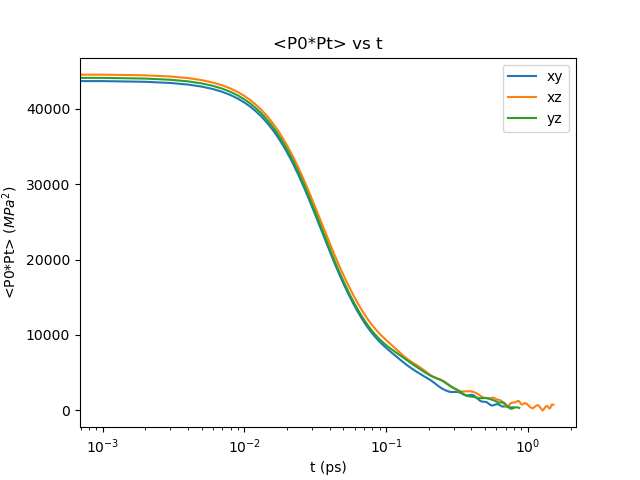

In [13]:
Image('P0Pt.png')

With the Green-Kubo solvers, you can do further analysis of the calculation, such as check the identified cutoff and play around with how sensitive kappa estimates are to the cutoff.

In [14]:
gkxy = results_dict['gkxy']
gkxz = results_dict['gkxz']
gkyz = results_dict['gkyz']

In [15]:
print(gkxy.index_cut, gkxz.index_cut, gkyz.index_cut)

787 1515 870


Text(0, 0.5, 'cutoff index')

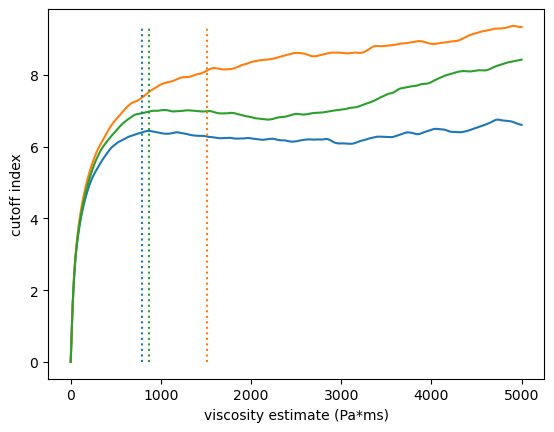

In [16]:
muxys = []
muxzs = []
muyzs = []

cutoffs = [i for i in range(0, 5000)]
for i in cutoffs:
    muxys.append(gkxy.mu(index_cut=i))
    muxzs.append(gkxz.mu(index_cut=i))
    muyzs.append(gkyz.mu(index_cut=i))
    
plt.plot(cutoffs, uc.get_in_units(muxys, viscosity_unit), 'C0')
plt.plot(cutoffs, uc.get_in_units(muxzs, viscosity_unit), 'C1')
plt.plot(cutoffs, uc.get_in_units(muyzs, viscosity_unit), 'C2')

ymin = uc.get_in_units(np.min([muxys, muxzs, muyzs]), viscosity_unit)
ymax = uc.get_in_units(np.max([muxys, muxzs, muyzs]), viscosity_unit)

plt.plot([gkxy.index_cut, gkxy.index_cut], [ymin, ymax], 'C0:')
plt.plot([gkxz.index_cut, gkxz.index_cut], [ymin, ymax], 'C1:')
plt.plot([gkyz.index_cut, gkyz.index_cut], [ymin, ymax], 'C2:')

plt.xlabel(f'viscosity estimate ({viscosity_unit})')
plt.ylabel(f'cutoff index')

Text(0, 0.5, 'fluctuation')

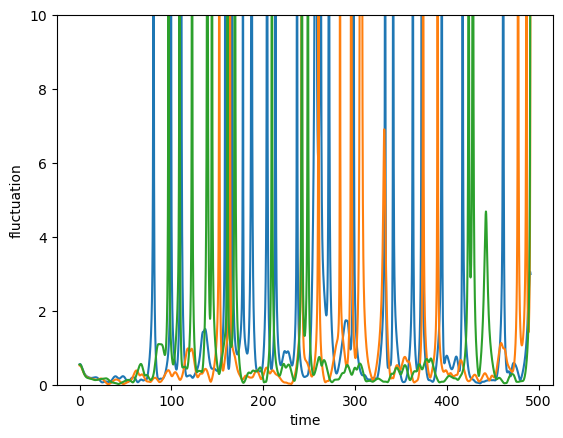

In [17]:
tmax = 5000
plt.plot(gkxy.time[:tmax], gkxy.fluctuation[:tmax])
plt.plot(gkxz.time[:tmax], gkxz.fluctuation[:tmax])
plt.plot(gkyz.time[:tmax], gkyz.fluctuation[:tmax])

plt.ylim(0, 10)
plt.xlabel(f'time')
plt.ylabel(f'fluctuation')

In [21]:
gkxy.acf

array([ 1.70349782e-06,  1.70228824e-06,  1.69866979e-06, ...,
       -2.66748222e-07, -2.74152191e-07, -2.81579637e-07],
      shape=(1000001,))

In [23]:
nsamples = np.arange(gkxy.acf.shape[0], 0, -1)
nsamples

array([1000001, 1000000,  999999, ...,       3,       2,       1],
      shape=(1000001,))

(-0.0001, 0.0001)

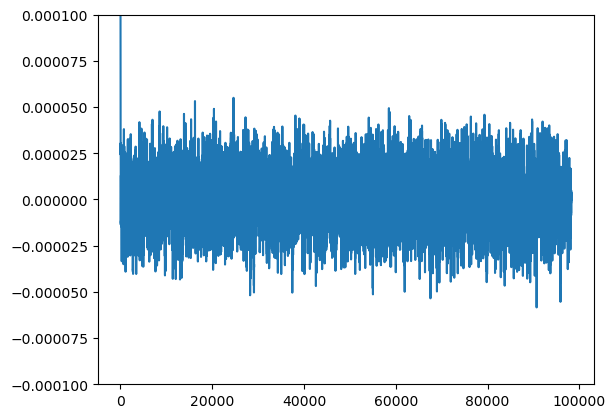

In [26]:
plt.plot(gkxy.time, gkxy.acf*nsamples**0.5)
plt.ylim(-0.0001, 0.0001)

In [49]:
var = np.var(gkxy.acf[500000:]*nsamples[500000:]**0.5)

(0.0, 100.0)

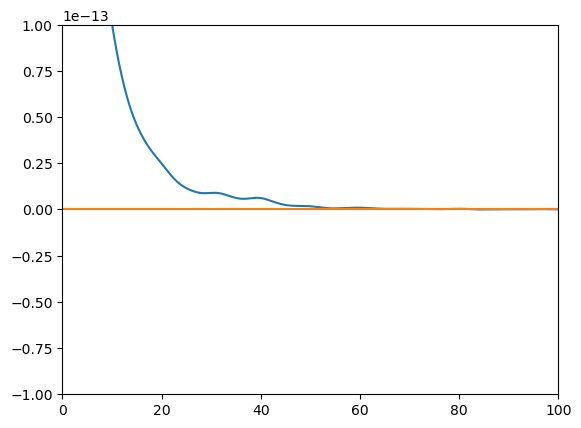

In [61]:
plt.plot(gkxy.time, gkxy.acf**2)
plt.plot(gkxy.time, var/nsamples)
plt.ylim(-1e-13, 1e-13)
plt.xlim(0, 100)

(0.0, 100.0)

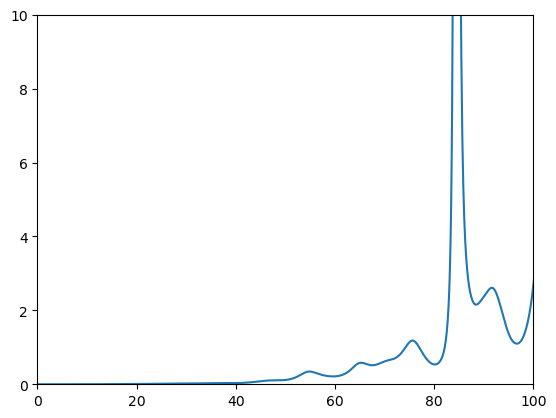

In [66]:
plt.plot(gkxy.time, (var/nsamples) / gkxy.acf**2)
plt.ylim(0, 10)

plt.xlim(0, 100)

In [ ]:
plt.plot(gkxy.time, gkxy.acf)

### 4.3. Optional: Clean calculation files

The calculation may generate output files when it runs.  Calling calculation.clean_files() will delete any generated files to keep the workspace clean.

In [18]:
calculation.clean_files()